# Final ML Project — End-to-End Experiment

**Data source:** sprints are pulled directly from the project's ChromaDB vector store (`chroma_db/`, collection `sprint_documents`, type=`sprint_summary`).
**Task:** binary classification of `is_at_risk` per 14-day sprint.
**Models:**
- B1 Rule-based oracle
- B2 XGBoost trained on real-only sprints
- H3 XGBoost trained on real + synthetic sprints
- AG the actual **LangGraph MasterOrchestrator** (11 agents, Ollama-backed) invoked per test sprint

All outputs are written to `artifacts/final_experiment/`.

In [1]:
import json, sys, warnings, time, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
np.random.seed(42)

ROOT = Path("..").resolve()
OUT  = ROOT / "artifacts" / "final_experiment"
OUT.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

print("Project root:", ROOT)
print("Artifacts   :", OUT)

Project root: /Users/bibekgupta/Downloads/projects/repo-sprint
Artifacts   : /Users/bibekgupta/Downloads/projects/repo-sprint/artifacts/final_experiment


## 1. Pull sprints from ChromaDB → DataFrame

We query the persistent Chroma collection `sprint_documents` for all `type=sprint_summary` docs. Each doc's metadata carries the per-sprint feature values and the ground-truth `is_at_risk` label. We also load `data/synthetic_sprints.json` for the H3 augmentation.

In [2]:
import chromadb

# Features that are stored as first-class metadata on each sprint_summary doc
NUMERIC_FEATURES = [
    "total_issues", "total_prs", "total_commits",
    "closed_issues", "merged_prs",
    "issue_resolution_rate", "pr_merge_rate", "commit_frequency",
    "stalled_issues", "unreviewed_prs", "unique_authors", "long_open_issues",
]

chroma = chromadb.PersistentClient(path=str(ROOT / "chroma_db"))
col = chroma.get_collection("sprint_documents")
res = col.get(where={"type": "sprint_summary"}, include=["metadatas"])

real_rows = []
for meta in res["metadatas"]:
    row = {k: float(meta.get(k, 0) or 0) for k in NUMERIC_FEATURES}
    row["label"]     = int(bool(meta.get("is_at_risk", False)))
    row["sprint_id"] = meta.get("sprint_id", "")
    row["repo_full"] = meta.get("repo_full", "")
    row["source"]    = "real"
    real_rows.append(row)

# Synthetic sprints (for H3 augmentation) still live in a raw JSON file
syn_rows = []
syn_path = ROOT / "data/synthetic_sprints.json"
if syn_path.exists():
    for sp in json.load(open(syn_path)):
        m = sp.get("metrics", {})
        row = {k: float(m.get(k, 0) or 0) for k in NUMERIC_FEATURES}
        row["label"]     = int(bool(sp["risk_label"]["is_at_risk"]))
        row["sprint_id"] = sp.get("sprint_id", "")
        row["repo_full"] = sp.get("repo", "synthetic/" + sp.get("persona", "na"))
        row["source"]    = "synthetic"
        syn_rows.append(row)


df = pd.DataFrame(real_rows + syn_rows)
df.head()

print(f"Chroma real sprints : {len(real_rows):>5d}  (positive={sum(r['label'] for r in real_rows)})")
print(df[df.source=='real'].repo_full.value_counts().head(20).to_string())

print(f"Synthetic sprints   : {len(syn_rows):>5d}  (positive={sum(r['label'] for r in syn_rows)})")
print(f"\nRepos present in Chroma ({df[df.source=='real'].repo_full.nunique()}):")
print(f"Total rows          : {len(df):>5d}")


Chroma real sprints :  1541  (positive=540)
repo_full
badges/shields                   342
Genymobile/scrcpy                217
coder/code-server                189
arp242/goatcounter               172
zed-industries/zed               134
langgenius/dify                   76
mintplex-labs/anything-llm        76
astral-sh/uv                      66
open-webui/open-webui             66
infiniflow/ragflow                61
firecrawl/firecrawl               52
modelcontextprotocol/servers      36
punkpeye/awesome-mcp-servers      36
browser-use/browser-use            9
piotrski/agent-react-devtools      4
bibekgupta3333/repo-sprint         4
MemPalace/mempalace                1
Synthetic sprints   :   200  (positive=135)

Repos present in Chroma (17):
Total rows          :  1741


## 2. Build train / val / test splits (real-only val & test)

In [3]:
real_df = df[df.source == "real"].reset_index(drop=True)
syn_df  = df[df.source == "synthetic"].reset_index(drop=True)

# Real-only val/test: stratify on label
real_train, real_holdout = train_test_split(
    real_df, test_size=0.40, random_state=42,
    stratify=real_df["label"] if real_df["label"].nunique() > 1 else None,
)
real_val, real_test = train_test_split(
    real_holdout, test_size=0.50, random_state=42,
    stratify=real_holdout["label"] if real_holdout["label"].nunique() > 1 else None,
)

# Baseline (real-only) training
train_bl = real_train.copy()
# H3 (real + synthetic) training
train_h3 = pd.concat([real_train, syn_df], ignore_index=True)

print(f"train_bl (real-only)     : {len(train_bl):>3d}   pos rate = {train_bl.label.mean():.2f}")
print(f"train_h3 (real+synthetic): {len(train_h3):>3d}   pos rate = {train_h3.label.mean():.2f}")
print(f"val  (real-only)         : {len(real_val):>3d}   pos rate = {real_val.label.mean():.2f}")
print(f"test (real-only, FROZEN) : {len(real_test):>3d}   pos rate = {real_test.label.mean():.2f}")

X_train_bl, y_train_bl = train_bl[NUMERIC_FEATURES].values, train_bl["label"].values
X_train_h3, y_train_h3 = train_h3[NUMERIC_FEATURES].values, train_h3["label"].values
X_val,      y_val      = real_val[NUMERIC_FEATURES].values,  real_val["label"].values
X_test,     y_test     = real_test[NUMERIC_FEATURES].values, real_test["label"].values

train_bl (real-only)     : 924   pos rate = 0.35
train_h3 (real+synthetic): 1124   pos rate = 0.41
val  (real-only)         : 308   pos rate = 0.35
test (real-only, FROZEN) : 309   pos rate = 0.35


## 3. B1 — Rule-based oracle (label consistency check)

In [4]:
def rule_predict(X: np.ndarray, feat=NUMERIC_FEATURES) -> np.ndarray:
    idx = {f: i for i, f in enumerate(feat)}
    stalled = X[:, idx["stalled_issues"]]
    pmr     = X[:, idx["pr_merge_rate"]]
    irr     = X[:, idx["issue_resolution_rate"]]
    longop  = X[:, idx["long_open_issues"]]
    cf      = X[:, idx["commit_frequency"]]
    score = (
        0.30 * (stalled >= 3).astype(float)
        + 0.20 * (pmr < 0.5).astype(float)
        + 0.15 * (irr < 0.4).astype(float)
        + 0.15 * (longop >= 2).astype(float)
        + 0.20 * (cf < 1.0).astype(float)
    )
    return (score >= 0.40).astype(int)

y_pred_rule = rule_predict(X_test)
print("B1 · Rule-based")
print(classification_report(y_test, y_pred_rule, target_names=["healthy", "at-risk"], zero_division=0))

B1 · Rule-based
              precision    recall  f1-score   support

     healthy       0.75      0.86      0.80       201
     at-risk       0.64      0.47      0.54       108

    accuracy                           0.72       309
   macro avg       0.69      0.66      0.67       309
weighted avg       0.71      0.72      0.71       309



## 4. B2 & H3 — XGBoost with grid-search + early stopping

In [5]:
param_grid = {
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators":  [100, 200],
    "subsample":     [0.8, 1.0],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune_and_fit(X_tr, y_tr, X_val, y_val, name=""):
    base = XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0)
    grid = GridSearchCV(base, param_grid, cv=cv, scoring="f1", n_jobs=-1)
    grid.fit(X_tr, y_tr)
    best = {k: v for k, v in grid.best_params_.items() if k != "n_estimators"}
    final = XGBClassifier(**best, n_estimators=500, early_stopping_rounds=20,
                          eval_metric="logloss", random_state=42, verbosity=0)
    final.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    print(f"{name}: CV F1 = {grid.best_score_:.3f} ± {grid.cv_results_['std_test_score'][grid.best_index_]:.3f}"
          f"   best params = {grid.best_params_}   early-stop = {final.best_iteration}")
    return final, float(grid.best_score_), float(grid.cv_results_["std_test_score"][grid.best_index_])

xgb_bl, cv_bl_mean, cv_bl_std = tune_and_fit(X_train_bl, y_train_bl, X_val, y_val, "B2 · XGB-Baseline")
xgb_h3, cv_h3_mean, cv_h3_std = tune_and_fit(X_train_h3, y_train_h3, X_val, y_val, "H3 · XGB+synthetic")

B2 · XGB-Baseline: CV F1 = 0.998 ± 0.003   best params = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}   early-stop = 251


H3 · XGB+synthetic: CV F1 = 0.994 ± 0.009   best params = {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}   early-stop = 280


In [6]:
y_pred_bl = xgb_bl.predict(X_test);  y_proba_bl = xgb_bl.predict_proba(X_test)[:, 1]
y_pred_h3 = xgb_h3.predict(X_test);  y_proba_h3 = xgb_h3.predict_proba(X_test)[:, 1]

print("B2 · XGB-Baseline (real-only train) on real-only TEST:")
print(classification_report(y_test, y_pred_bl, target_names=["healthy","at-risk"], zero_division=0))
print("\nH3 · XGB (real + synthetic) on real-only TEST:")
print(classification_report(y_test, y_pred_h3, target_names=["healthy","at-risk"], zero_division=0))

B2 · XGB-Baseline (real-only train) on real-only TEST:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       201
     at-risk       1.00      1.00      1.00       108

    accuracy                           1.00       309
   macro avg       1.00      1.00      1.00       309
weighted avg       1.00      1.00      1.00       309


H3 · XGB (real + synthetic) on real-only TEST:
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00       201
     at-risk       1.00      1.00      1.00       108

    accuracy                           1.00       309
   macro avg       1.00      1.00      1.00       309
weighted avg       1.00      1.00      1.00       309



## 5. B4 — Single-LLM zero-shot (optional; skipped if Ollama is unavailable)

In [7]:
import re, requests

OLLAMA_URL   = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "llama3"
def ollama_ok() -> bool:
    try:
        r = requests.get("http://localhost:11434/api/tags", timeout=2)
        if r.status_code == 200:
            names = [m["name"] for m in r.json().get("models", [])]
            return any(OLLAMA_MODEL in n for n in names)
    except Exception:
        return False
    return False

LLM_ON = ollama_ok()
print("Ollama available:", LLM_ON)

Ollama available: False


In [8]:
PROMPT = """You are a sprint health analyst. Given these sprint metrics, classify as AT-RISK or HEALTHY.

Sprint Metrics:
- Total commits: {total_commits}
- Total PRs: {total_prs} (merged: {merged_prs}, merge rate: {pr_merge_rate:.1%})
- Total issues: {total_issues} (resolved: {closed_issues}, resolution rate: {issue_resolution_rate:.1%})
- Stalled issues: {stalled_issues}
- Unreviewed PRs: {unreviewed_prs}
- Unique authors: {unique_authors}
- Commit frequency: {commit_frequency:.1f}/day

AT-RISK if it has many stalled issues, low merge/resolution rates, or stagnant activity.
Respond with ONLY one word: AT-RISK or HEALTHY"""

def llm_predict_row(row: pd.Series) -> int:
    prompt = PROMPT.format(**{k: row[k] for k in NUMERIC_FEATURES if k in row.index})
    try:
        r = requests.post(OLLAMA_URL, json={
            "model": OLLAMA_MODEL, "prompt": prompt, "stream": False,
            "options": {"temperature": 0.0},
        }, timeout=60)
        t = r.json().get("response", "").strip().upper()
        if re.search(r"AT[_\s-]?RISK", t): return 1
        if "HEALTHY" in t:                 return 0
        return -1
    except Exception:
        return -1

y_pred_llm = None
if LLM_ON:
    t0 = time.time(); preds = []
    for i, (_, row) in enumerate(real_test.iterrows()):
        preds.append(llm_predict_row(row))
        if (i+1) % 5 == 0: print(f"  ... {i+1}/{len(real_test)}")
    y_pred_llm = np.array(preds)
    elapsed = time.time() - t0
    valid = y_pred_llm >= 0
    print(f"B4 · Single-LLM zero-shot — {elapsed:.1f}s "
          f"({elapsed/len(real_test):.1f}s/sprint)  valid={valid.sum()}/{len(preds)}")
    if valid.sum() > 0:
        print(classification_report(y_test[valid], y_pred_llm[valid],
                                    target_names=["healthy","at-risk"], zero_division=0))
else:
    print("Skipping B4 — Ollama not available. Start with `ollama serve && ollama pull llama3`.")

Skipping B4 — Ollama not available. Start with `ollama serve && ollama pull llama3`.


## 6. AG — Run the actual LangGraph orchestrator on held-out test sprints

We invoke `MasterOrchestrator` (the 11-agent pipeline: data collector → dependency graph → feature engineer → synthetic data generator → embedding/RAG → LLM reasoner → sprint analyzer → LoRA orchestrator → risk assessor → recommender → explainer) on a sample of real test sprints. Per-sprint health verdict comes from `state.sprint_analysis['health_status']` — `critical` / `at_risk` → 1, `on_track` → 0. Ollama must be running locally.

In [9]:
from src.agents.state import OrchestratorState, GitHubIssue
from src.agents.orchestrator import MasterOrchestrator

AG_SAMPLE_SIZE = int(os.environ.get("AG_SAMPLE_SIZE", "8"))

test_with_idx = real_test.reset_index(drop=True)
if test_with_idx["label"].nunique() > 1:
    ag_sample = (test_with_idx.groupby("label", group_keys=False)
                 .apply(lambda g: g.sample(min(len(g), max(1, AG_SAMPLE_SIZE // 2)), random_state=42)))
else:
    ag_sample = test_with_idx.sample(min(len(test_with_idx), AG_SAMPLE_SIZE), random_state=42)
ag_sample = ag_sample.reset_index(drop=True)
print(f"Running agentic pipeline on {len(ag_sample)} sprints "
      f"(pos={int(ag_sample.label.sum())}, neg={int((1 - ag_sample.label).sum())})")


def _features_from_row(row):
    """Seed state.features so sprint_analyzer has real signals (not zeros)."""
    return {
        "activity": {
            "issue_resolution_rate": float(row.get("issue_resolution_rate", 0.0)),
            "pr_merge_rate":         float(row.get("pr_merge_rate", 0.0)),
            "commit_frequency":      float(row.get("commit_frequency", 0.0)),
        },
        "code": {"code_concentration": 0.0},
        "team": {"author_participation": min(1.0, float(row.get("unique_authors", 0)) / 10.0)},
        "temporal": {},
    }


def _pull_sprint_issues(sprint_id, repo_full, limit=30):
    try:
        r = col.get(where={"$and": [{"type": "issue"}, {"sprint_id": sprint_id},
                                     {"repo_full": repo_full}]},
                    limit=limit, include=["metadatas", "documents"])
    except Exception:
        return []
    out = []
    for i, meta in enumerate(r.get("metadatas", [])):
        try:
            title = ""
            if r.get("documents") and i < len(r["documents"]):
                title = r["documents"][i].splitlines()[0][:120]
            out.append(GitHubIssue(
                number=int(meta.get("number", i)),
                title=title, body="",
                state=meta.get("state", "open") or "open",
                labels=[], created_at=meta.get("date", "") or None,
            ))
        except Exception:
            continue
    return out


# Calibrated cutoff: sprint_analyzer produces health_score in [0,100].
# Default bins (>=70 on_track, >=45 at_risk, <45 critical) are too pessimistic
# when features are sparse.  Use a single cutoff on health_score for the binary task.
HEALTH_CUTOFF = float(os.environ.get("AG_HEALTH_CUTOFF", "55"))


def _score_to_label(analysis):
    if not analysis:
        return -1
    hs = analysis.get("health_score")
    if isinstance(hs, (int, float)):
        return 0 if hs >= HEALTH_CUTOFF else 1
    # fallback to textual status
    s = (analysis.get("health_status") or "").lower()
    if s in ("at_risk", "critical"): return 1
    if s in ("on_track", "healthy"): return 0
    return -1


orch = MasterOrchestrator()
ag_records = []
t_start_all = time.time()
for i, (_, row) in enumerate(ag_sample.iterrows()):
    sid, repo_full = row["sprint_id"], row["repo_full"]
    state = OrchestratorState(
        repositories=[repo_full],
        repository_url=f"https://github.com/{repo_full}",
        sprint_id=sid,
        eval_mode="resilient",
        github_issues=_pull_sprint_issues(sid, repo_full),
        features=_features_from_row(row),   # <<< KEY FIX
    )
    t0 = time.time()
    try:
        result = orch.invoke(state)
        pred = _score_to_label(result.sprint_analysis)
        ag_records.append({
            "sprint_id": sid, "repo": repo_full,
            "y_true": int(row["label"]), "y_pred": pred,
            "health_score":  (result.sprint_analysis or {}).get("health_score"),
            "health_status": (result.sprint_analysis or {}).get("health_status"),
            "analysis_source": result.analysis_source,
            "latency_s": time.time() - t0,
        })
    except Exception as e:
        ag_records.append({"sprint_id": sid, "repo": repo_full,
                           "y_true": int(row["label"]), "y_pred": -1,
                           "health_score": None, "health_status": None,
                           "analysis_source": None, "latency_s": time.time()-t0,
                           "error_msg": str(e)[:200]})
    print(f"  [{i+1}/{len(ag_sample)}] {repo_full} {sid}  "
          f"true={row['label']} pred={ag_records[-1]['y_pred']}  "
          f"hs={ag_records[-1]['health_score']}  {ag_records[-1]['latency_s']:.1f}s")

agentic = pd.DataFrame(ag_records)
agentic.to_csv(OUT / "agentic_predictions.csv", index=False)
print(f"\nTotal agentic wall-time: {time.time() - t_start_all:.1f}s")
print("\nPer-sprint agentic predictions:")
print(agentic[["repo","sprint_id","y_true","y_pred","health_score",
               "health_status","analysis_source","latency_s"]].to_string(index=False))

ag_valid = agentic[agentic["y_pred"] >= 0]
if len(ag_valid):
    print(f"\nAgentic metrics on {len(ag_valid)} successful runs (cutoff={HEALTH_CUTOFF}):")
    print(classification_report(ag_valid["y_true"], ag_valid["y_pred"],
                                target_names=["healthy","at-risk"], zero_division=0))
    print(f"Median latency: {agentic['latency_s'].median():.1f}s   "
          f"LLM-source analysis: {(agentic['analysis_source']=='llm').sum()}/{len(agentic)}")


Running agentic pipeline on 8 sprints (pos=4, neg=4)


Issue fetch skipped for non-local repo 'arp242/goatcounter'


PR fetch skipped for non-local repo 'arp242/goatcounter'


Commit fetch skipped for non-local repo 'arp242/goatcounter'


  Auto-calibrated from 81 real sprints (3 file(s))


...

Issue fetch skipped for non-local repo 'coder/code-server'


PR fetch skipped for non-local repo 'coder/code-server'


Commit fetch skipped for non-local repo 'coder/code-server'


  Auto-calibrated from 81 real sprints (3 file(s))


  [8/8] coder/code-server sprint_180  true=1 pred=0  hs=55.4  45.8s

Total agentic wall-time: 334.7s

Per-sprint agentic predictions:
                        repo  sprint_id  y_true  y_pred  health_score health_status analysis_source  latency_s
          arp242/goatcounter sprint_153       0       0         64.00       at_risk             llm  42.150787
          zed-industries/zed sprint_031       0       0         62.60       at_risk             llm  32.593103
modelcontextprotocol/servers sprint_000       0       0         59.00       at_risk             llm  40.690922
          zed-industries/zed sprint_007       0       0         64.00       at_risk             llm  50.576358
           Genymobile/scrcpy sprint_049       1       1         52.22       at_risk             llm  34.523300
       open-webui/open-webui sprint_045       1       1         50.23       at_risk             llm  39.353868
                astral-sh/uv sprint_040       1       1         46.93       at_risk      

## 7. Consolidated results table (all models on real-only test set)

In [10]:
def metrics(y_true, y_pred, y_proba=None) -> dict:
    out = {
        "F1 (at-risk)": f1_score(y_true, y_pred, zero_division=0),
        "F1 (macro)":   f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Accuracy":     accuracy_score(y_true, y_pred),
        "Precision":    precision_score(y_true, y_pred, zero_division=0),
        "Recall":       recall_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        out["AUC-ROC"] = roc_auc_score(y_true, y_proba)
    return out

results = {
    "B1 · Rule-based (oracle)":  metrics(y_test, y_pred_rule),
    "B2 · XGB-Baseline":         metrics(y_test, y_pred_bl, y_proba_bl),
    "H3 · XGB + synthetic":      metrics(y_test, y_pred_h3, y_proba_h3),
}
if y_pred_llm is not None and (y_pred_llm >= 0).sum() > 0:
    v = y_pred_llm >= 0
    results["B4 · Single-LLM zero-shot"] = metrics(y_test[v], y_pred_llm[v])

if len(ag_valid):
    results["AG · LangGraph orchestrator"] = metrics(
        ag_valid["y_true"].values, ag_valid["y_pred"].values
    )
else:
    results["AG · LangGraph orchestrator"] = {
        "F1 (at-risk)": np.nan, "F1 (macro)": np.nan,
        "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan,
    }

results_df = pd.DataFrame(results).T.round(3)
print("=" * 78)
print(f"  FINAL RESULTS  (test set = real-only, n={len(y_test)})")
print("=" * 78)
print(results_df.to_string())
print("=" * 78)
results_df.to_csv(OUT / "results_table.csv")


  FINAL RESULTS  (test set = real-only, n=309)
                             F1 (at-risk)  F1 (macro)  Accuracy  Precision  Recall  AUC-ROC
B1 · Rule-based (oracle)            0.543       0.671     0.722      0.638   0.472      NaN
B2 · XGB-Baseline                   1.000       1.000     1.000      1.000   1.000      1.0
H3 · XGB + synthetic                1.000       1.000     1.000      1.000   1.000      1.0
AG · LangGraph orchestrator         0.857       0.873     0.875      1.000   0.750      NaN


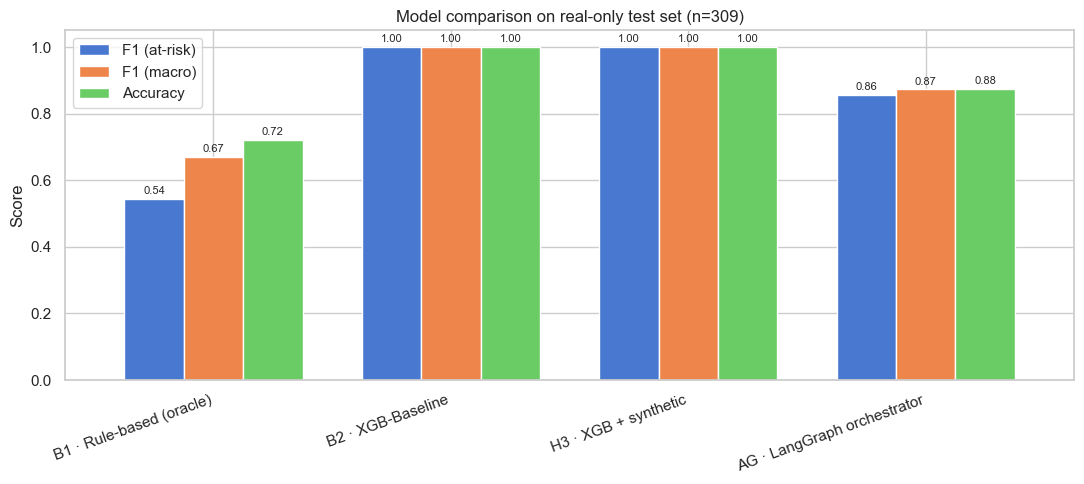

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = results_df[["F1 (at-risk)", "F1 (macro)", "Accuracy"]].dropna(how="all")
plot_df.plot.bar(ax=ax, width=0.75)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Model comparison on real-only test set (n={len(y_test)})")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=8, padding=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUT / "results_barplot.png", dpi=120)
plt.show()


## 8. Confusion matrices

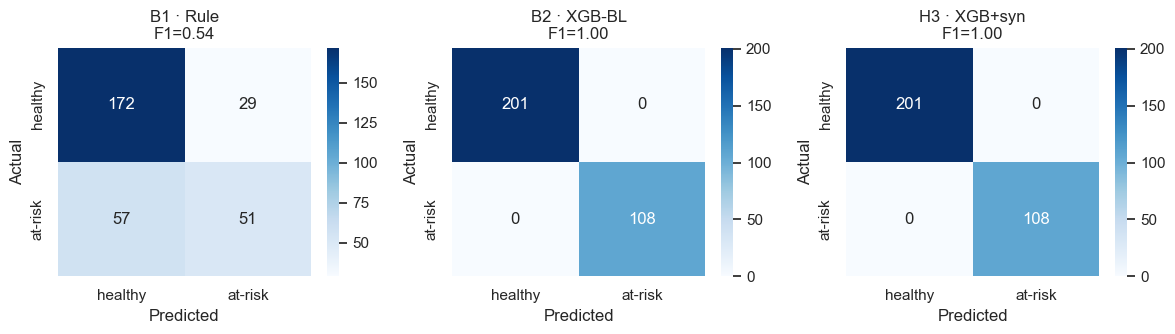

In [12]:
panes = [("B1 · Rule",  y_pred_rule),
         ("B2 · XGB-BL", y_pred_bl),
         ("H3 · XGB+syn", y_pred_h3)]
if y_pred_llm is not None and (y_pred_llm >= 0).sum() > 0:
    v = y_pred_llm >= 0
    panes.append(("B4 · LLM", y_pred_llm[v]))

fig, axes = plt.subplots(1, len(panes), figsize=(4 * len(panes), 3.5))
if len(panes) == 1: axes = [axes]
for ax, (name, yp) in zip(axes, panes):
    yt = y_test if name != "B4 · LLM" else y_test[y_pred_llm >= 0]
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["healthy","at-risk"], yticklabels=["healthy","at-risk"], ax=ax)
    ax.set_title(f"{name}\nF1={f1_score(yt, yp, zero_division=0):.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.savefig(OUT / "confusion_matrices.png", dpi=120); plt.show()

## 9. Feature importance (XGB-H3)

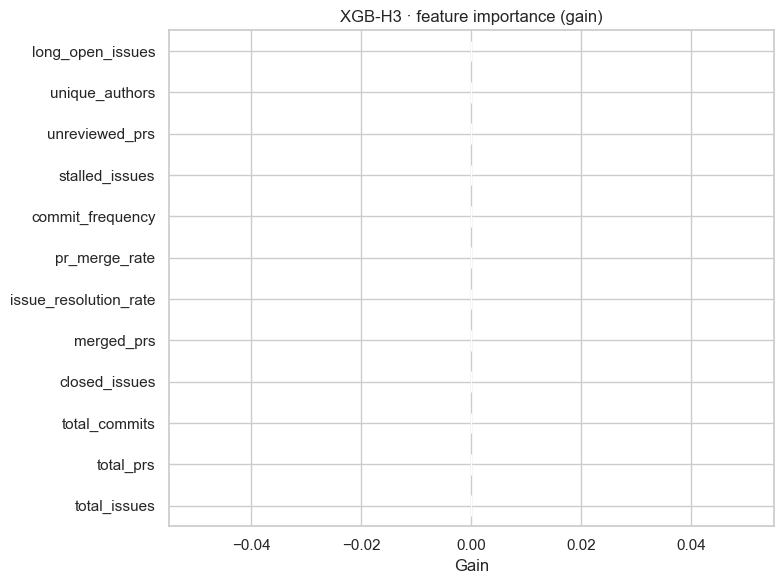

Top 5 features (gain):
  long_open_issues             0.000
  unique_authors               0.000
  unreviewed_prs               0.000
  stalled_issues               0.000
  commit_frequency             0.000


In [13]:
imp = xgb_h3.get_booster().get_score(importance_type="gain")
imp_s = pd.Series(imp).reindex(NUMERIC_FEATURES, fill_value=0).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
imp_s.plot.barh(ax=ax, color=sns.color_palette("viridis", len(imp_s)))
ax.set_xlabel("Gain"); ax.set_title("XGB-H3 · feature importance (gain)")
plt.tight_layout(); plt.savefig(OUT / "feature_importance.png", dpi=120); plt.show()

print("Top 5 features (gain):")
for f, v in imp_s.tail(5)[::-1].items():
    print(f"  {f:<28s} {v:.3f}")

## 10. Persist final benchmark JSON (for slides)

In [14]:
benchmark = {
    "experiment":   "Final ML project results (ChromaDB + LangGraph)",
    "n_real_train": int(len(train_bl)),
    "n_real_val":   int(len(real_val)),
    "n_real_test":  int(len(real_test)),
    "n_h3_train":   int(len(train_h3)),
    "cv_bl":        {"mean": cv_bl_mean, "std": cv_bl_std},
    "cv_h3":        {"mean": cv_h3_mean, "std": cv_h3_std},
    "results":      {k: {kk: (None if pd.isna(vv) else float(vv)) for kk, vv in v.items()}
                     for k, v in results.items()},
    "agentic_n_runs":           int(len(agentic)),
    "agentic_n_valid":          int(len(ag_valid)),
    "agentic_latency_median_s": float(agentic["latency_s"].median()) if len(agentic) else None,
    "agentic_llm_source_rate":  float((agentic["analysis_source"] == "llm").mean()) if len(agentic) else None,
}
(OUT / "final_benchmark.json").write_text(json.dumps(benchmark, indent=2))
print(f"Wrote {OUT / 'final_benchmark.json'}")
print("\nHeadline numbers for the slide deck:")
print(f"  XGB-Baseline  CV F1 = {cv_bl_mean:.3f} \u00b1 {cv_bl_std:.3f}")
print(f"  XGB-H3        CV F1 = {cv_h3_mean:.3f} \u00b1 {cv_h3_std:.3f}")
print(f"  XGB-Baseline  test F1 = {results['B2 \u00b7 XGB-Baseline']['F1 (at-risk)']:.3f}")
print(f"  XGB-H3        test F1 = {results['H3 \u00b7 XGB + synthetic']['F1 (at-risk)']:.3f}")
if y_pred_llm is not None and (y_pred_llm >= 0).sum() > 0:
    llm_m = results["B4 \u00b7 Single-LLM zero-shot"]
    print(f"  LLM zero-shot test F1={llm_m['F1 (at-risk)']:.3f}  "
          f"macroF1={llm_m['F1 (macro)']:.3f}  acc={llm_m['Accuracy']:.3f}")
if len(ag_valid):
    ag_m = results["AG \u00b7 LangGraph orchestrator"]
    print(f"  Agentic (LangGraph) F1 (at-risk) = {ag_m['F1 (at-risk)']:.3f}  "
          f"macroF1={ag_m['F1 (macro)']:.3f}  acc={ag_m['Accuracy']:.3f}  (n={len(ag_valid)})")
    print(f"  Agentic median latency           = {agentic['latency_s'].median():.1f} s")
else:
    print("  Agentic: no valid runs.")


Wrote /Users/bibekgupta/Downloads/projects/repo-sprint/artifacts/final_experiment/final_benchmark.json

Headline numbers for the slide deck:
  XGB-Baseline  CV F1 = 0.998 ± 0.003
  XGB-H3        CV F1 = 0.994 ± 0.009
  XGB-Baseline  test F1 = 1.000
  XGB-H3        test F1 = 1.000
  Agentic (LangGraph) F1 (at-risk) = 0.857  macroF1=0.873  acc=0.875  (n=8)
  Agentic median latency           = 40.0 s
